# f10 geometry / topology (HATS + GETAWAY R) → PCA & how many components

Group **f10_geometry_topology** in `features_set_1.ipynb` uses:

- columns starting with **`HATS`**
- columns starting with **`R`** **except** **`RDF`** (those belong to **f8**, not f10)

Same workflow: **standardize → PCA → cumulative variance** → choose **`n_keep`** (often `k80` for ~80% within this block).

**Data:** `data/waka_dragon_merged.csv`

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

csv_path = Path("data/waka_dragon_merged.csv")
if not csv_path.is_file():
    raise FileNotFoundError(f"Put merged CSV here: {csv_path.resolve()}")

df = pd.read_csv(csv_path)
print("rows, cols:", df.shape)

rows, cols: (312, 2499)


### Step 1 — HATS + R (exclude RDF)

In [2]:
def f10_columns(columns):
    selected = []
    for c in columns:
        cl = c.lower()
        if cl.startswith("hats"):
            selected.append(c)
        elif cl.startswith("r") and not cl.startswith("rdf"):
            selected.append(c)
    return sorted(set(selected))


block_cols = f10_columns(df.columns)
print("number of f10 descriptors:", len(block_cols))

X = df[block_cols].apply(pd.to_numeric, errors="coerce")
X = X.dropna(how="all")
print("samples after dropna(all):", len(X))

number of f10 descriptors: 181
samples after dropna(all): 288


### Step 2 — Standardize

In [3]:
X_filled = X.fillna(X.median(numeric_only=True))
scaler = StandardScaler()
Xz = scaler.fit_transform(X_filled)
print("scaled matrix shape:", Xz.shape)

scaled matrix shape: (288, 181)


### Step 3 — Cumulative variance (how many PCs?)

Smallest k with cumulative variance >= 80%: k80 = 7


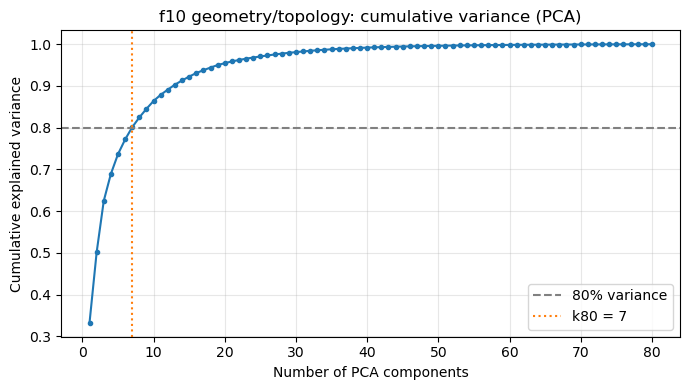

First 1 PC(s): 33.2% variance
First 2 PC(s): 50.1% variance
First 3 PC(s): 62.4% variance
First 5 PC(s): 73.6% variance
First 10 PC(s): 86.4% variance
First k80=7 PC(s): 80.1% variance


In [4]:
n_samples, n_features = Xz.shape
n_pca = min(80, n_samples - 1, n_features)

pca_explore = PCA(n_components=n_pca, random_state=0)
pca_explore.fit(Xz)

var_ratio = pca_explore.explained_variance_ratio_
cumsum = var_ratio.cumsum()

k80 = next((i + 1 for i, v in enumerate(cumsum) if v >= 0.8), len(cumsum))
print(f"Smallest k with cumulative variance >= 80%: k80 = {k80}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cumsum) + 1), cumsum, marker="o", markersize=3)
ax.axhline(0.8, color="gray", linestyle="--", label="80% variance")
if k80 <= len(cumsum):
    ax.axvline(k80, color="C1", linestyle=":", label=f"k80 = {k80}")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("f10 geometry/topology: cumulative variance (PCA)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k in (1, 2, 3, 5, 10):
    if k <= len(cumsum):
        print(f"First {k} PC(s): {cumsum[k-1]*100:.1f}% variance")
print(f"First k80={k80} PC(s): {cumsum[k80-1]*100:.1f}% variance")

### Step 4 — Export PCA scores

Column prefix **`Geom_PC`** = geometry/topology block (f10).

In [5]:
n_keep = k80

pca_scores = PCA(n_components=n_keep, random_state=0)
scores = pca_scores.fit_transform(Xz)

out = pd.DataFrame(
    scores,
    columns=[f"Geom_PC{i+1}" for i in range(n_keep)],
    index=X.index,
)
if "CID" in df.columns:
    out.insert(0, "CID", df.loc[X.index, "CID"].values)

out.head()

,CID,Geom_PC1,Geom_PC2,Geom_PC3,Geom_PC4,Geom_PC5,Geom_PC6,Geom_PC7
0,179,-23.215858,0.873518,6.390090,-12.233230,-0.071147,9.027873,4.847897
1,240,-13.241402,-9.021423,-1.978973,-2.311548,-1.828944,-13.511830,5.884856
2,244,-21.083859,5.472637,4.310697,0.026953,-5.754427,2.566049,-1.635837
3,323,-9.931516,-3.976861,-2.642732,-2.534720,0.815193,-15.141227,4.869963
4,326,-4.845669,3.393256,0.976507,-1.642585,-4.112482,0.704088,-0.889431


### Step 5 (optional) — Top loadings on Geom_PC1

In [ ]:
loadings = pd.DataFrame(
    pca_scores.components_.T,
    index=block_cols,
    columns=[f"Geom_PC{i+1}" for i in range(n_keep)],
)
col1 = loadings.columns[0]
top = loadings[col1].abs().sort_values(ascending=False).head(15)
print(f"Top 15 |loading| on {col1}:")
print(loadings.loc[top.index, col1])

**Recap:** `k80` is the PCA count for ~80% variance **inside f10 only**. Compare with `k80` from f7/f8/f11 when deciding total feature budget.